In [1]:
import numpy as np
import glob
import os
from collections import Counter

# CSV 파일 찾기
files = sorted(glob.glob('data/data/**/*.csv', recursive=True))

print("전체 파일 개수:", len(files))
print("예시 파일:", files[0])

# 첫 번째 CSV 읽기
x = np.loadtxt(files[0], delimiter=',', skiprows=1)

print("배열 모양:", x.shape)
print("최솟값:", x.min())
print("최댓값:", x.max())

# 피험자별 시행 수
subjects = [
    os.path.basename(os.path.dirname(f))
    for f in files
]

print("피험자별 시행 수:", Counter(subjects))

전체 파일 개수: 250
예시 파일: data/data/A/a (1).csv
배열 모양: (3000, 2)
최솟값: -3.53656
최댓값: 4.33942
피험자별 시행 수: Counter({'A': 50, 'B': 50, 'C': 50, 'D': 50, 'E': 50})


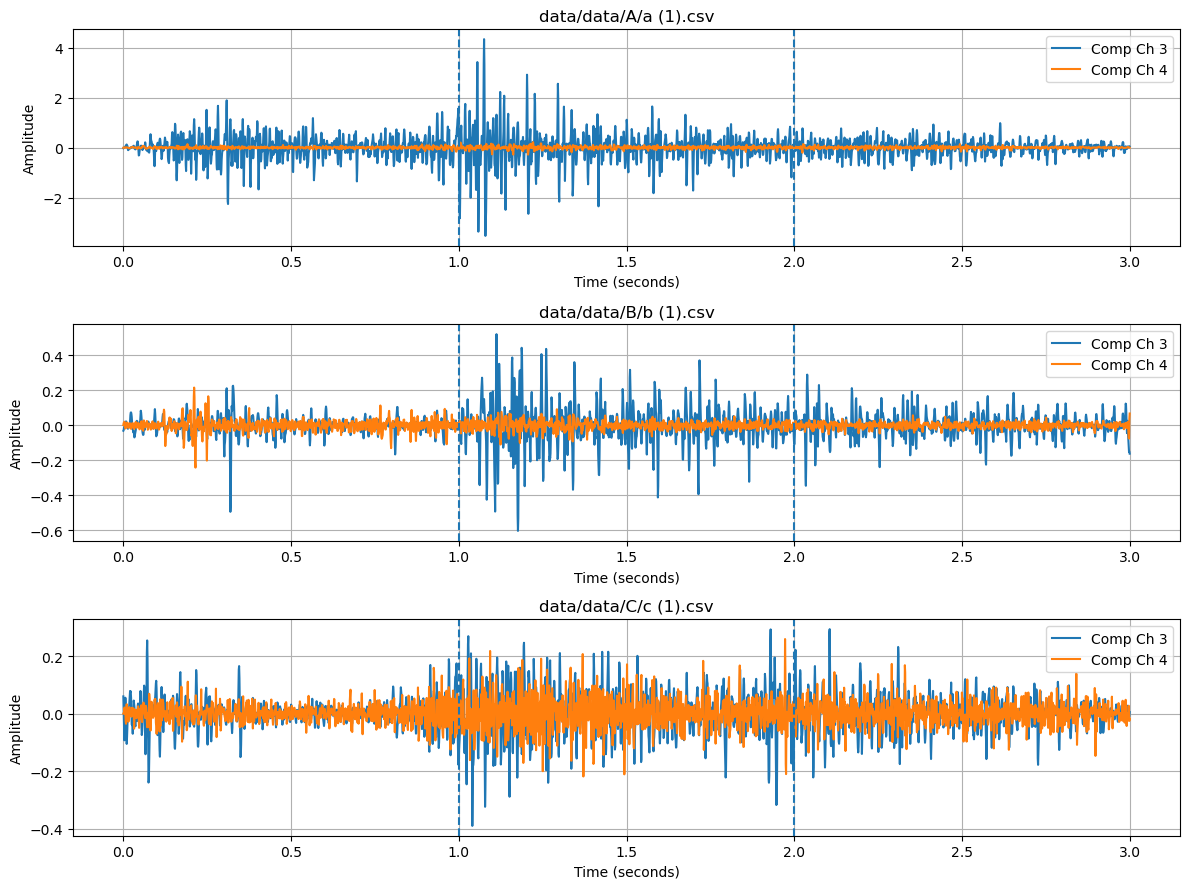

In [3]:
import matplotlib.pyplot as plt

# 샘플링 주파수
fs = 1000

# A, B, C 피험자의 첫 번째 시행 선택
selected_files = [
    files[0],    # A
    files[50],   # B
    files[100]   # C
]

# 그래프 그리기
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

for ax, file in zip(axes, selected_files):
    signal = np.loadtxt(file, delimiter=',', skiprows=1)
    time = np.arange(len(signal)) / fs

    ax.plot(time, signal[:, 0], label='Comp Ch 3')
    ax.plot(time, signal[:, 1], label='Comp Ch 4')

    ax.axvline(1, linestyle='--')
    ax.axvline(2, linestyle='--')

    ax.set_title(file)
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Amplitude')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

## 4. 관찰 내용

1. 0~1초 구간에서는 신호의 변화가 비교적 작게 나타났다.

2. 1~2초 구간에서는 손동작으로 인해 신호의 진폭이 크게 변하는 모습을 확인하였다.

3. 피험자마다 신호의 크기와 변화 양상이 달라 개인별 차이가 있음을 확인하였다.

## 5. 논문 Table 1 정리

| 측정 부위 | 피험자 수 | 채널 수 | 동작 | 특징 + 모델 | 정확도 (%) |
|---|---:|---:|---|---|---:|
| Wrist | 50 | 8 | Clapping | GAN + DNN | 97.94 |
| Forearm | 80 | 8 | Smartphone unlock | Siamese CNN | 92.06 |
| Forearm | 5 | 4 | 6 hand gestures | DWT/EWT/EMD + CNN | ~95.62 |
| Biceps/Triceps | 40 | 12 | 3 hand gestures | CQT + CNN | 97.50 |
| Forearm | 21 | 4 | Hand opening | DWT/CWT + CNN | ~99.21 |
| Palm | 5 | 2 | Doorknob rotation | CWT + DenseNet161 | 94.00 |

### 비교

기존 연구는 손목이나 전완에서 주로 손동작을 측정했지만, 이 연구는 손바닥에서 문손잡이 회전이라는 일상 동작을 사용한다.

또한 2채널만 사용하고 CWT와 DenseNet161을 적용하여 손바닥 sEMG 신호를 분석하였다.